<a href="https://colab.research.google.com/github/haritraman/job_fraud_detection_nuerosymbolic/blob/main/nuero_early_emscad_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================= INSTALL =================
!pip install shap gdown transformers -q

# ================= IMPORTS =================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import re
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display, HTML

from transformers import DistilBertModel, DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🔥 Using device:", device)

🔥 Using device: cuda


Downloading...
From: https://drive.google.com/uc?id=15lcwS3slEEmOF6J_D25I3Ed5Oq6zmmdI
To: /content/emscad.csv
100%|██████████| 59.1M/59.1M [00:01<00:00, 42.5MB/s]


🧠 Extracting Neurosymbolic Rules from Metadata...

🔥 Final Class Distribution (Notice the Imbalance):
label
0    15186
1      687
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Starting Neurosymbolic Training...

Epoch 1 | Batch 0/794 | Loss: 0.6411
Epoch 1 | Batch 50/794 | Loss: 0.0894
Epoch 1 | Batch 100/794 | Loss: 0.1179
Epoch 1 | Batch 150/794 | Loss: 4.4630
Epoch 1 | Batch 200/794 | Loss: 0.3409
Epoch 1 | Batch 250/794 | Loss: 0.0978
Epoch 1 | Batch 300/794 | Loss: 0.0039
Epoch 1 | Batch 350/794 | Loss: 0.0042
Epoch 1 | Batch 400/794 | Loss: 3.6279
Epoch 1 | Batch 450/794 | Loss: 0.4991
Epoch 1 | Batch 500/794 | Loss: 0.0342
Epoch 1 | Batch 550/794 | Loss: 1.2975
Epoch 1 | Batch 600/794 | Loss: 2.2500
Epoch 1 | Batch 650/794 | Loss: 0.0024
Epoch 1 | Batch 700/794 | Loss: 0.0518
Epoch 1 | Batch 750/794 | Loss: 0.0286

✅ Epoch 1/5
Train Acc: 94.83% | Val Acc: 96.82%

Epoch 2 | Batch 0/794 | Loss: 2.8894
Epoch 2 | Batch 50/794 | Loss: 8.0162
Epoch 2 | Batch 100/794 | Loss: 0.2668
Epoch 2 | Batch 150/794 | Loss: 0.0060
Epoch 2 | Batch 200/794 | Loss: 4.4165
Epoch 2 | Batch 250/794 | Loss: 0.0031
Epoch 2 | Batch 300/794 | Loss: 0.0061
Epoch 2 | Batch 350/

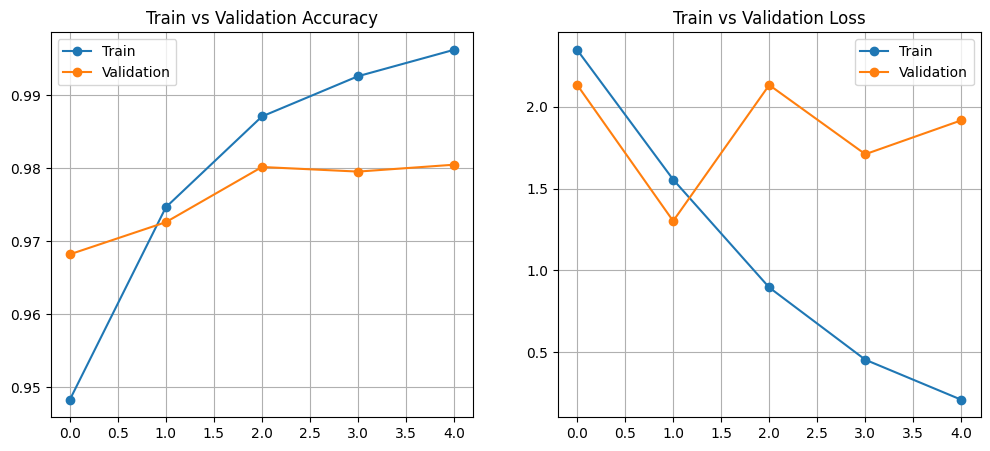

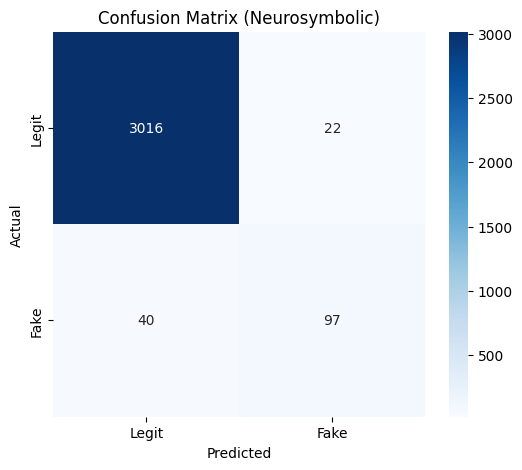


📊 Classification Report:

              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      3038
        Fake       0.82      0.71      0.76       137

    accuracy                           0.98      3175
   macro avg       0.90      0.85      0.87      3175
weighted avg       0.98      0.98      0.98      3175

🔥 ROC-AUC: 0.9550246752809907
✅ Model Saved.



In [ ]:


# ================= SYMBOLIC RULES ENGINE =================
def apply_symbolic_rules(row):
    """
    Applies 10 Neurosymbolic Rules based on ablation study.
    Returns a 10-dimensional binary vector [1, 0, 0, 1, ...]
    """
    desc = str(row.get('description', '')).lower()
    title = str(row.get('title', '')).lower()
    raw_title = str(row.get('title', ''))
    profile = str(row.get('company_profile', '')).lower()

    # Handle missing logo safely
    try:
        logo = int(row.get('has_company_logo', 0))
    except:
        logo = 0

    vec = [0] * 15

    # R1: Payment/PII in description
    if re.search(r'(registration fee|processing fee|security deposit|ssn|social security|bank account)', desc): vec[0] = 1
    # R2: External Comms
    if re.search(r'(whatsapp|telegram|@gmail|@yahoo|@hotmail|@outlook)', desc): vec[1] = 1
    # R3: Urgency / High Pressure
    if re.search(r'(urgent hiring|apply immediately|limited seats|hired on the spot|no interview|start immediately)', desc): vec[2] = 1
    # R4: Unrealistic Offer (Entry level + High pay)
    if re.search(r'(no experience|entry level)', desc) and re.search(r'(\$5000|\$5,000|high salary|easy work|1000/week)', desc): vec[3] = 1
    # R5: Clickbait Title
    if (raw_title.isupper() and len(raw_title) > 4) or re.search(r'(earn|weekly|quick money|immediate|hiring now)', title): vec[4] = 1
    # R6: High Risk Role
    if re.search(r'(data entry|virtual assistant|package handler|reshipping)', title): vec[5] = 1
    # R7: Ghost Profile
    if len(profile) < 50: vec[6] = 1
    # R8: Vague Profile without links
    if re.search(r'(fast-growing|leading organization|multinational)', profile) and not re.search(r'(www\.|http|\.com|\.org|\.net)', profile): vec[7] = 1
    # R9: Low Effort Setup (No Logo + Ghost Profile)
    if logo == 0 and vec[6] == 1: vec[8] = 1
    # R10: Phishing Funnel (No Logo + External Comms)
    if logo == 0 and vec[1] == 1: vec[9] = 1
    if re.search(r'(usdt|crypto wallet|bitcoin|ethereum|metamask|trust wallet)', desc): vec[10] = 1

    # R12: Sketchy URLs
    if re.search(r'(bit\.ly|tinyurl\.com|google forms|forms\.gle)', desc): vec[11] = 1

    # R13: Click Farms / Task Scams
    if re.search(r'(download our app|rate 5 stars|app testing|click tasks|daily tasks)', desc): vec[12] = 1

    # R14: Zero Skill Requirements
    if re.search(r'(must be 18|basic english|internet connection|smartphone required)', desc): vec[13] = 1

    # R15: Spammy Punctuation (Excessive Exclamation Marks)
    if desc.count('!') > 4: vec[14] = 1

    return vec

# ================= LOAD DATA (EMSCAD ONLY) =================
def load_emscad_data():
    # 1. Download and Load EMSCAD
    emscad_id = '15lcwS3slEEmOF6J_D25I3Ed5Oq6zmmdI'
    gdown.download(f'https://drive.google.com/uc?id={emscad_id}', 'emscad.csv', quiet=False)
    emscad = pd.read_csv('emscad.csv', encoding='latin-1')

    # 2. Format Target
    emscad['label'] = emscad['fraudulent'].map({'f': 0, 't': 1})

    # 3. Preprocess Text
    emscad['text'] = emscad['title'].fillna('') + " " + emscad['description'].fillna('')
    emscad['text'] = emscad['text'].apply(lambda x: re.sub(r'<[^>]+>', '', str(x)).strip())
    emscad.drop_duplicates(subset=['text'], inplace=True)

    # 4. Apply Neurosymbolic Rules
    print("🧠 Extracting Neurosymbolic Rules from Metadata...")
    emscad['rule_vector'] = emscad.apply(apply_symbolic_rules, axis=1)

    print("\n🔥 Final Class Distribution (Notice the Imbalance):")
    print(emscad['label'].value_counts())

    return emscad['text'].tolist(), emscad['rule_vector'].tolist(), emscad['label'].tolist()

texts, rule_vectors, labels = load_emscad_data()


# ================= DATASET =================
class HybridJobDataset(Dataset):
    def __init__(self, texts, rule_vectors, labels):
        self.texts = texts
        self.rule_vectors = rule_vectors
        self.labels = labels
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            padding='max_length',
            truncation=True,
            max_length=384,
            return_tensors='pt'
        )
        return {
            'ids': enc['input_ids'].flatten(),
            'mask': enc['attention_mask'].flatten(),
            'rules': torch.tensor(self.rule_vectors[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.float)
        }

# ================= SPLIT =================
train_texts, val_texts, train_rules, val_rules, train_labels, val_labels = train_test_split(
    texts, rule_vectors, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_ds = HybridJobDataset(train_texts, train_rules, train_labels)
val_ds = HybridJobDataset(val_texts, val_rules, val_labels)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

# ================= NEUROSYMBOLIC MODEL =================
class NeurosymbolicClassifier(nn.Module):
    def __init__(self, rule_dim=15):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        # 768 (BERT embedding) + 10 (Symbolic Rules) = 778
        self.classifier = nn.Linear(768 + rule_dim, 1)

    def forward(self, input_ids, attention_mask, rules):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        # FEATURE FUSION: Glue the BERT output and Symbolic Rules together
        combined = torch.cat((cls, rules), dim=1)

        return self.classifier(combined)

model = NeurosymbolicClassifier(rule_dim=15).to(device)

# ================= OPTIMIZER & LOSS =================
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
pos_weight = torch.tensor([len(train_labels)/sum(train_labels)]).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ================= TRAIN =================
EPOCHS = 5
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

print("\n🚀 Starting Neurosymbolic Training...\n")

for epoch in range(EPOCHS):
    model.train()
    train_loss, correct_train, total_train = 0, 0, 0

    for i, batch in enumerate(train_loader):
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        rules = batch['rules'].to(device)
        labels_batch = batch['label'].unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(ids, mask, rules)
        loss = loss_fn(outputs, labels_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct_train += (preds == labels_batch).sum().item()
        total_train += labels_batch.size(0)

        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_acc = correct_train / total_train
    avg_train_loss = train_loss / len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss, correct_val, total_val = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            rules = batch['rules'].to(device)
            labels_batch = batch['label'].unsqueeze(1).to(device)

            outputs = model(ids, mask, rules)
            loss = loss_fn(outputs, labels_batch)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct_val += (preds == labels_batch).sum().item()
            total_val += labels_batch.size(0)

    val_acc = correct_val / total_val
    avg_val_loss = val_loss / len(val_loader)

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f"\n✅ Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%\n")

print("🔥 Training Complete!")

# ================= PLOTS =================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history['train_acc'], marker='o')
plt.plot(history['val_acc'], marker='o')
plt.title("Train vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history['train_loss'], marker='o')
plt.plot(history['val_loss'], marker='o')
plt.title("Train vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

# ================= CONFUSION MATRIX =================
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in val_loader:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        rules = batch['rules'].to(device)
        labels_batch = batch['label'].to(device)

        outputs = model(ids, mask, rules)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fake'],
            yticklabels=['Legit','Fake'])
plt.title("Confusion Matrix (Neurosymbolic)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=['Legit','Fake']))

roc = roc_auc_score(all_labels, all_probs)
print("🔥 ROC-AUC:", roc)

# ================= SAVE MODEL =================
torch.save(model.state_dict(), "emscad_neurosymbolic_shap.pth")
print("✅ Model Saved.\n")

# ================= EXPLAINABLE AI (CAPTUM) =================


🔍 Running SHAP Explainability Visualization...

🎲 Randomly selected Fake Job (Index 1235)
📝 Text Preview: Office/Personal Assistant (15-20 hours per week) Currently seeking an Office Assistant for our home office on a casual part time basis. This job involves personal and office assistance. Ideally, we are seeking someone who has previous experience in a...

Generating SHAP Waterfall Plot...



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.45s/it]               


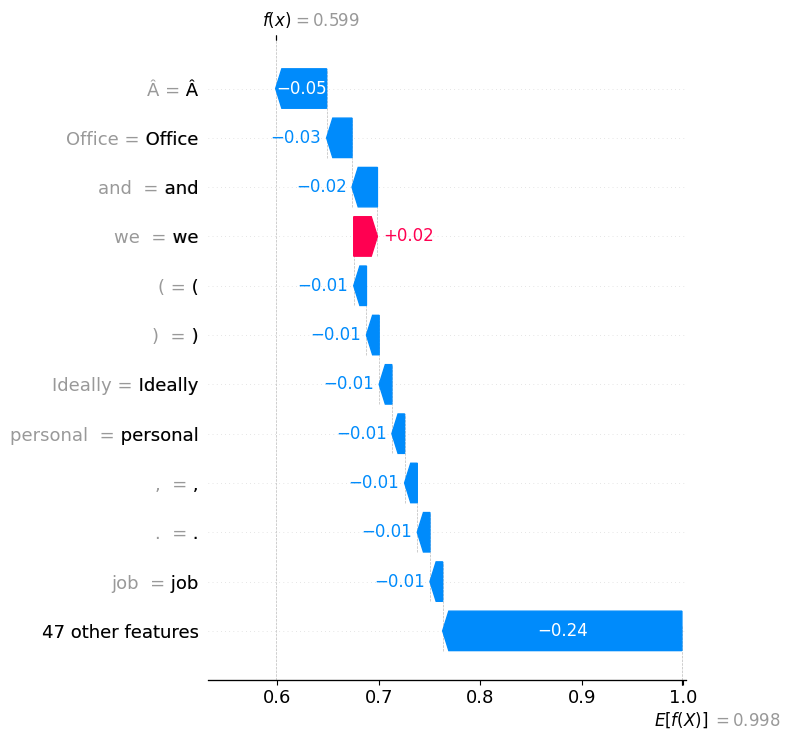

In [ ]:
# ================= EXPLAINABLE AI (SHAP - WATERFALL PLOT) =================
import shap
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

print("🔍 Running SHAP Explainability Visualization...\n")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# 1. Create a Wrapper Function for SHAP
def predict_for_shap(texts):
    model.eval()
    probs = []

    for text in texts:
        # Reconstruct a dummy row so our rule engine still works dynamically
        dummy_row = {
            'description': text,
            'title': text,
            'company_profile': text,
            'has_company_logo': 0  # Default to 0 for the test
        }

        # Calculate rules on the fly
        rule_vector = apply_symbolic_rules(dummy_row)

        # Tokenize
        enc = tokenizer(text, padding='max_length', truncation=True, max_length=256, return_tensors='pt')
        input_ids = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        rules_tensor = torch.tensor([rule_vector], dtype=torch.float).to(device)

        # Predict
        with torch.no_grad():
            output = model(input_ids, attention_mask, rules_tensor)
            prob = torch.sigmoid(output).item()

        probs.append(prob)

    return np.array(probs)

import random

# 2. Find a RANDOM "Fake" example from the validation set
fake_indices = []
for i, label in enumerate(val_labels):
    if label == 1:
        # Keep the length filter so the graphic stays clean and readable
        if len(val_texts[i].split()) < 150:
            fake_indices.append(i)

# If no short ones are found, just grab all fake ones
if not fake_indices:
    for i, label in enumerate(val_labels):
        if label == 1:
            fake_indices.append(i)

if fake_indices:
    # 🎲 Pick a random fake job from our list
    fake_idx = random.choice(fake_indices)
    text_to_explain = val_texts[fake_idx]

    print(f"🎲 Randomly selected Fake Job (Index {fake_idx})")
    print(f"📝 Text Preview: {text_to_explain[:250]}...\n")
    print("Generating SHAP Waterfall Plot...\n")

    # 3. Initialize SHAP Explainer
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_for_shap, masker)

    # 4. Calculate SHAP values
    shap_values = explainer([text_to_explain])

    # 5. Render the Waterfall Plot
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[0], max_display=12, show=False)
    plt.tight_layout()
    plt.show()

else:
    print("No fake jobs found in the validation set to explain.")

In [ ]:
from google.colab import files
files.download("emscad_neurosymbolic_shap.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>